# Simulasi Dinamika Sistem Penyangga (Buffer) Darah Manusia
Pemodelan ketahanan *buffer* bikarbonat ($HCO_3^-$) terhadap infusi asam laktat konstan menggunakan integrasi numerik Persamaan Diferensial Biasa (ODE).

---

In [11]:
# Import library
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import root_scalar
plt.style.use('seaborn-v0_8-whitegrid')

### 1. Inisialisasi Parameter Biologis & Kondisi Awal
Bagian ini mendefinisikan nilai awal cairan fisiologis darah pada ekuilibrium (pH 7.4). Konstanta laju reaksi dihitung berdasarkan konstanta kesetimbangan asam ($pK_a$) bikarbonat pada suhu tubuh.

In [12]:
# Kondisi normal darah manusia
pH_awal = 7.4
H_awal = 10**(-pH_awal)      # konsentrasi ion H+ awal (Molar)
HCO3_awal = 0.024            # konsentrasi Bikarbonat normal ~24 mM (Molar)
H2CO3_awal = 0.0012          # konsentrasi Asam Karbonat normal ~1.2 mM (Molar)
y0 = [H_awal, HCO3_awal, H2CO3_awal]

# Reaksi: H2CO3 <--> H+ + HCO3-
Ka = (H_awal * HCO3_awal) / H2CO3_awal
kr = 1.0e5                   # laju asosiasi
kf = Ka * kr                 # laju disosiasi

# variabel infusi asam laktat
v_asam = 2.5e-7 

t_max = 1200
t = np.linspace(0, t_max, t_max + 1)
t0_injeksi = 100
t1_injeksi = 120
print("Parameter awal berhasil diinisialisasi.")

Parameter awal berhasil diinisialisasi.


### EKSPERIMEN 01: skenario kontrol (tanpa intervensi buffer)

implementasi kinetika sistem:
1. $\frac{d[H^+]}{dt} = k_f[H_2CO_3] - k_r[H^+][HCO_3^-] + v_{asam}$
2. $\frac{d[HCO_3^-]}{dt} = k_f[H_2CO_3] - k_r[H^+][HCO_3^-]$
3. $\frac{d[H_2CO_3]}{dt} = -k_f[H_2CO_3] + k_r[H^+][HCO_3^-]$

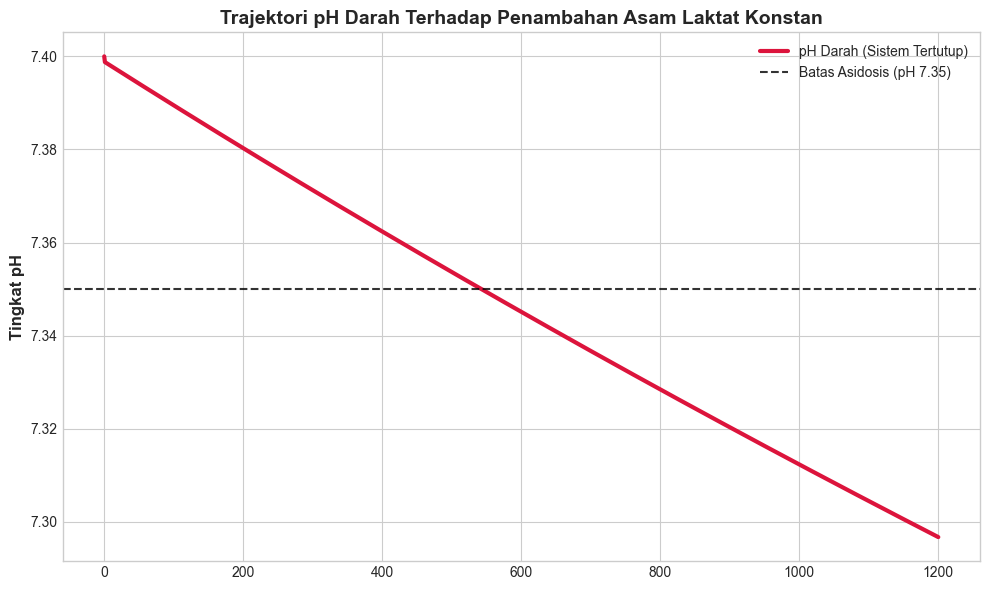

[!] Batas asidosis klinis (pH 7.35) tertembus pada detik ke-543.0


In [13]:
def kinetika_sistem(y, t, kf, kr, v_asam, t0, t1, v_injeksi_val):
    """
    Fungsi ODE Universal: 
    Jika v_injeksi_val = 0, sistem menjadi Skenario Kontrol.
    Jika v_injeksi_val > 0, sistem menjadi Skenario Intervensi.
    """
    H, HCO3, H2CO3 = y
    
    laju_disosiasi = kf * H2CO3
    laju_asosiasi = kr * H * HCO3

    # Logika aktivasi injeksi pada rentang waktu tertentu
    v_injeksi = v_injeksi_val if t0 <= t <= t1 else 0.0
    
    dH_dt = laju_disosiasi - laju_asosiasi + v_asam
    dHCO3_dt = laju_disosiasi - laju_asosiasi + v_injeksi 
    dH2CO3_dt = -laju_disosiasi + laju_asosiasi
    
    return [dH_dt, dHCO3_dt, dH2CO3_dt]

# gunakan odeint untuk menyelesaikan sistem persamaan diferensial
solusi = odeint(kinetika_sistem, y0, t, args=(kf, kr, v_asam, t0_injeksi, t1_injeksi, 0.0), hmax=1.0)

H_hasil_1 = solusi[:, 0]
HCO3_hasil_1 = solusi[:, 1] * 1000
H2CO3_hasil_1 = solusi[:, 2] * 1000 
pH_hasil_1 = -np.log10(H_hasil_1)

fig, ax1 = plt.subplots(figsize=(10, 6))

# trajektori pH darah terhadap penambahan asam laktat konstan
ax1.plot(t, pH_hasil_1, color='crimson', linewidth=3, label='pH Darah (Sistem Tertutup)')
ax1.axhline(y=7.35, color='black', linestyle='--', alpha=0.8, label='Batas Asidosis (pH 7.35)')

ax1.set_ylabel('Tingkat pH', fontsize=12, fontweight='bold')
ax1.set_title('Trajektori pH Darah Terhadap Penambahan Asam Laktat Konstan', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')

plt.tight_layout()
plt.savefig('assets/trajektori-pH-darah.png', dpi=300)
plt.show()

idx_asidosis = np.argmax(pH_hasil_1 < 7.35)
waktu_asidosis = t[idx_asidosis]

if idx_asidosis > 0:
    print(f"[!] Batas asidosis klinis (pH 7.35) tertembus pada detik ke-{waktu_asidosis:.1f}")
else:
    print("[-] Sistem berhasil menahan asidosis selama rentang waktu simulasi.")

### EKSPERIMEN 02: Analisis konsentrasi buffer dengan tipping point

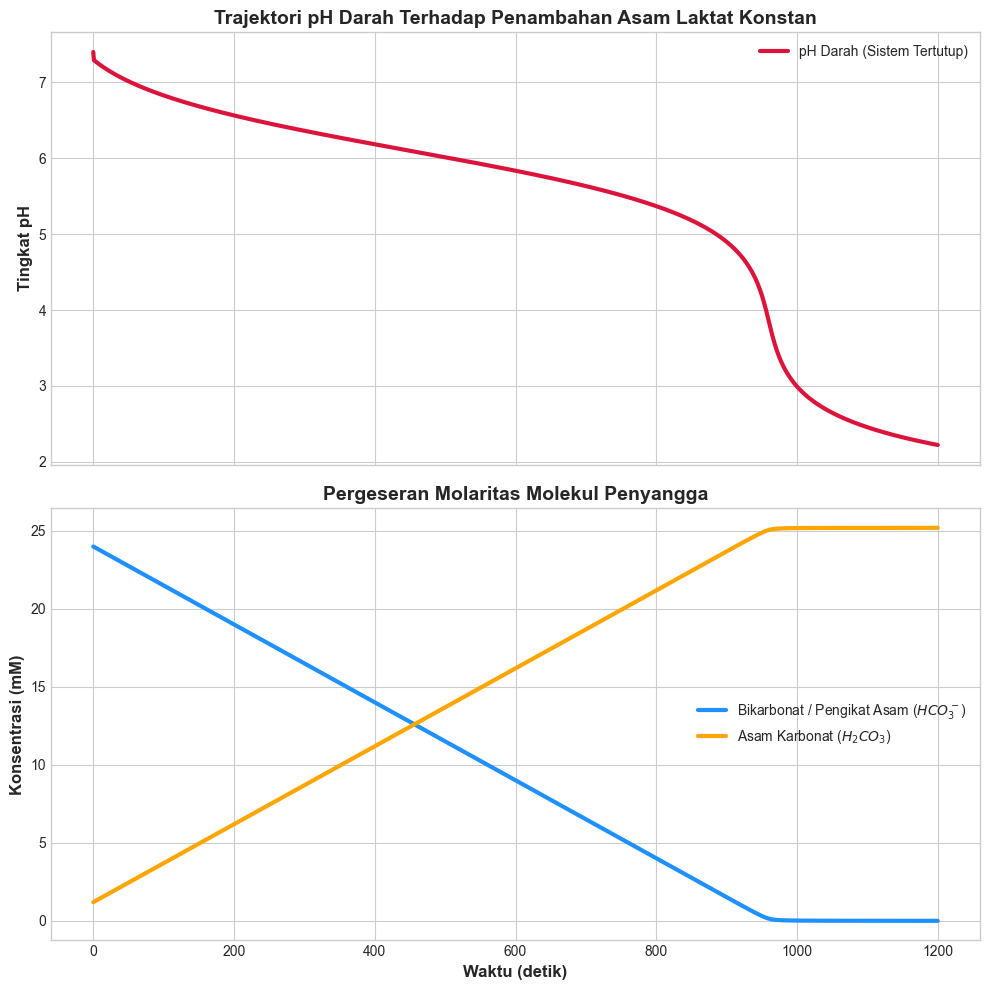

[!] Kegagalan Sistem: Molekul penyangga bikarbonat jenuh pada detik ke-942.0


In [14]:
v_asam_hiperbola = 2.5e-5
solusi_2 = odeint(kinetika_sistem, y0, t, args=(kf, kr, v_asam_hiperbola, t0_injeksi, t1_injeksi, 0.0), hmax=1.0)

H_hasil_2 = solusi_2[:, 0]
HCO3_hasil_2 = solusi_2[:, 1] * 1000
H2CO3_hasil_2 = solusi_2[:, 2] * 1000
pH_hasil_2 = -np.log10(H_hasil_2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# trajektori pH darah terhadap konsentrasi buffer
ax1.plot(t, pH_hasil_2, color='crimson', linewidth=3, label='pH Darah (Sistem Tertutup)')
ax1.set_ylabel('Tingkat pH', fontsize=12, fontweight='bold')
ax1.set_title('Trajektori pH Darah Terhadap Penambahan Asam Laktat Konstan', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')

ax2.plot(t, HCO3_hasil_2, color='dodgerblue', linewidth=3, label='Bikarbonat / Pengikat Asam ($HCO_3^-$)')
ax2.plot(t, H2CO3_hasil_2, color='orange', linewidth=3, label='Asam Karbonat ($H_2CO_3$)')
ax2.set_xlabel('Waktu (detik)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Konsentrasi (mM)', fontsize=12, fontweight='bold')
ax2.set_title('Pergeseran Molaritas Molekul Penyangga', fontsize=14, fontweight='bold')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('assets/konsentrasi-buffer.png', dpi=300)
plt.show()

idx_habis = np.argmax(HCO3_hasil_2 < 0.5)
waktu_habis = t[idx_habis]
    
if idx_habis > 0:
    print(f"[!] Kegagalan Sistem: Molekul penyangga bikarbonat jenuh pada detik ke-{waktu_habis:.1f}")
else:
    print("[-] Molekul penyangga masih tersedia hingga akhir simulasi.")

### EKSPERIMEN 03: Skenario intervensi buffer dengan injeksi NaHCO3

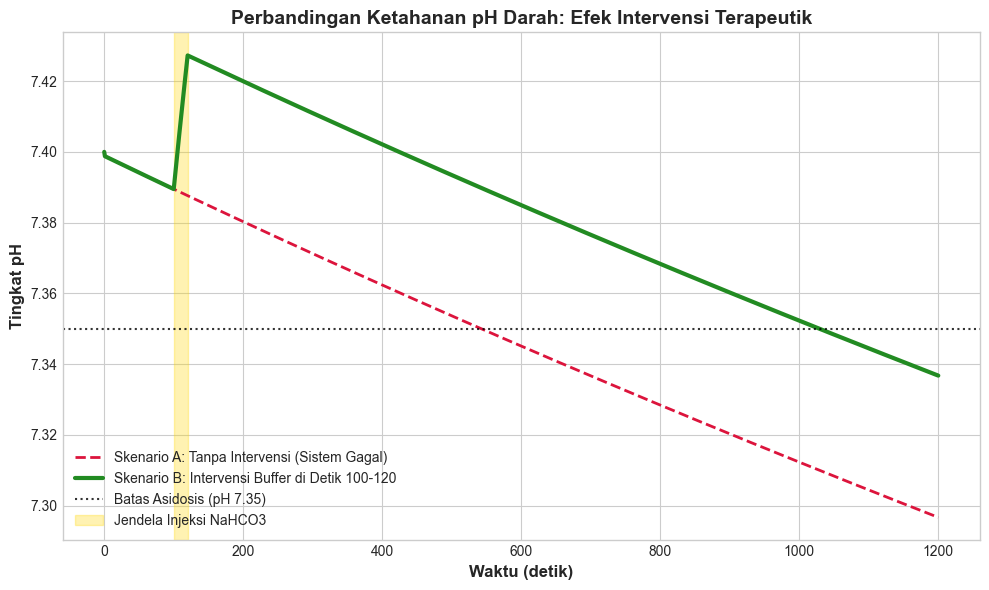

[!] Batas asidosis klinis (pH 7.35) tertembus pada detik ke-1030.0


In [15]:
solusi_3 = odeint(kinetika_sistem, y0, t, args=(kf, kr, v_asam, 100, 120, 0.0001145), hmax=1.0)

H_hasil_3 = solusi_3[:, 0]
HCO3_hasil_3 = solusi_3[:, 1] * 1000  # Konversi ke mM
pH_hasil_3 = -np.log10(H_hasil_3)

plt.figure(figsize=(10, 6))
plt.plot(t, pH_hasil_1, color='crimson', linewidth=2, linestyle='--', 
         label='Skenario A: Tanpa Intervensi (Sistem Gagal)')
plt.plot(t, pH_hasil_3, color='forestgreen', linewidth=3, 
         label='Skenario B: Intervensi Buffer di Detik 100-120')
plt.axhline(y=7.35, color='black', linestyle=':', alpha=0.8, label='Batas Asidosis (pH 7.35)')

# area intervensi
plt.axvspan(100, 120, color='gold', alpha=0.3, label='Jendela Injeksi NaHCO3')

plt.title('Perbandingan Ketahanan pH Darah: Efek Intervensi Terapeutik', fontsize=14, fontweight='bold')
plt.xlabel('Waktu (detik)', fontsize=12, fontweight='bold')
plt.ylabel('Tingkat pH', fontsize=12, fontweight='bold')
plt.legend(loc='lower left')

plt.tight_layout()
plt.savefig('assets/simulasi-intervensi.png', dpi=300)
plt.show()

idx_asidosis_3 = np.argmax(pH_hasil_3 < 7.35)
waktu_asidosis_3 = t[idx_asidosis_3]

if idx_asidosis_3 > 0:
    print(f"[!] Batas asidosis klinis (pH 7.35) tertembus pada detik ke-{waktu_asidosis_3:.1f}")
else:
    print("[-] Sistem berhasil menahan asidosis selama rentang waktu simulasi.")

### EKSPERIMEN 03.5: Skenario intervensi buffer dengan injeksi NaHCO3 berlebihan

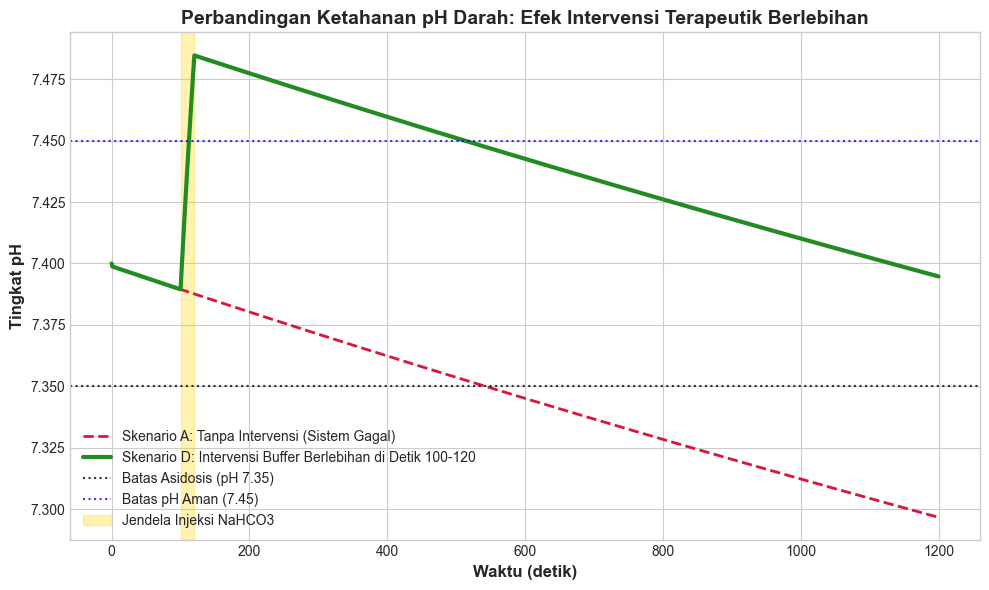

[!] Batas pH aman (pH 7.45) tertembus pada detik ke-113.0


In [16]:
solusi_35 = odeint(kinetika_sistem, y0, t, args=(kf, kr, v_asam, 100, 120, 0.0003), hmax=1.0)

H_hasil_35 = solusi_35[:, 0]
HCO3_hasil_35 = solusi_35[:, 1] * 1000  # Konversi ke mM
pH_hasil_35 = -np.log10(H_hasil_35)

plt.figure(figsize=(10, 6))
plt.plot(t, pH_hasil_1, color='crimson', linewidth=2, linestyle='--', 
         label='Skenario A: Tanpa Intervensi (Sistem Gagal)')
plt.plot(t, pH_hasil_35, color='forestgreen', linewidth=3, 
         label='Skenario D: Intervensi Buffer Berlebihan di Detik 100-120')
plt.axhline(y=7.35, color='black', linestyle=':', alpha=0.8, label='Batas Asidosis (pH 7.35)')
plt.axhline(y=7.45, color='blue', linestyle=':', alpha=0.8, label='Batas pH Aman (7.45)')

# area intervensi
plt.axvspan(100, 120, color='gold', alpha=0.3, label='Jendela Injeksi NaHCO3')

plt.title('Perbandingan Ketahanan pH Darah: Efek Intervensi Terapeutik Berlebihan', fontsize=14, fontweight='bold')

plt.xlabel('Waktu (detik)', fontsize=12, fontweight='bold')
plt.ylabel('Tingkat pH', fontsize=12, fontweight='bold')
plt.legend(loc='lower left')

plt.tight_layout()
plt.savefig('assets/simulasi-intervensi-berlebihan.png', dpi=300)
plt.show()

idx_asidosis_35 = np.argmax(pH_hasil_35 > 7.45)
waktu_asidosis_35 = t[idx_asidosis_35]

if idx_asidosis_35 > 0:
    print(f"[!] Batas pH aman (pH 7.45) tertembus pada detik ke-{waktu_asidosis_35:.1f}")
else:
    print("[-] Sistem berhasil menahan asidosis selama rentang waktu simulasi.")

[+] Dosis Injeksi Optimal (pH max 7.45) ditemukan: 1.851140e-04 M/s


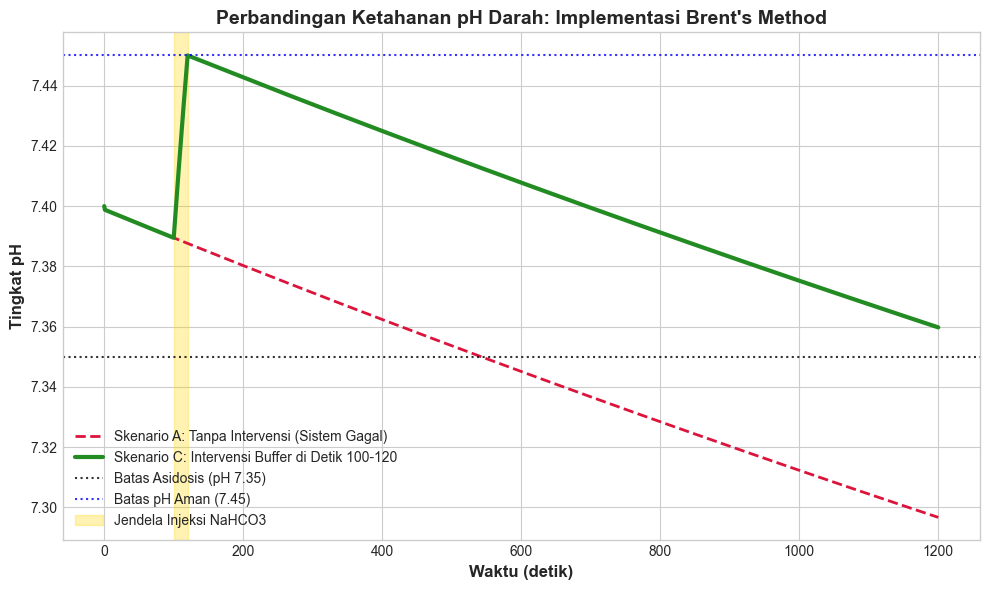

[-] Sistem berhasil menahan asidosis selama rentang waktu simulasi.


In [17]:
def evaluasi_puncak_pH(v_injeksi_uji, y0, t, kf, kr, v_asam, t0, t1, target_pH=7.45):
    # implementasi Brent's Method
    
    sol = odeint(kinetika_sistem, y0, t, 
                 args=(kf, kr, v_asam, t0, t1, v_injeksi_uji), hmax=1.0)
    
    H = sol[:, 0]
    pH = -np.log10(np.clip(H, 1e-14, None)) 
    
    # target pencarian: selisih antara puncak pH dan batas aman (7.45) harus 0
    return np.max(pH) - target_pH

def dosis_injeksi_optimal(y0, t, kf, kr, v_asam, t0, t1):
    # implementasi root finding algorithm dari SciPy
   
    hasil_pencarian = root_scalar(
        evaluasi_puncak_pH, 
        args=(y0, t, kf, kr, v_asam, t0, t1, 7.45), 
        bracket=[0.0, 1e-3], 
        method='brentq'
    )
    
    if hasil_pencarian.converged:
        return hasil_pencarian.root
    else:
        raise ValueError("[-] Algoritma gagal menemukan konvergensi dosis yang aman.")


dosis_aman_maksimal = dosis_injeksi_optimal(y0, t, kf, kr, v_asam, t0_injeksi, t1_injeksi)
print(f"[+] Dosis Injeksi Optimal (pH max 7.45) ditemukan: {dosis_aman_maksimal:.6e} M/s")


solusi_4 = odeint(kinetika_sistem, y0, t, args=(kf, kr, v_asam, t0_injeksi, t1_injeksi, dosis_aman_maksimal), hmax=1.0)

H_hasil_4 = solusi_4[:, 0]
HCO3_hasil_4 = solusi_4[:, 1] * 1000  # Konversi ke mM
pH_hasil_4 = -np.log10(H_hasil_4)

plt.figure(figsize=(10, 6))
plt.plot(t, pH_hasil_1, color='crimson', linewidth=2, linestyle='--', 
         label='Skenario A: Tanpa Intervensi (Sistem Gagal)')
plt.plot(t, pH_hasil_4, color='forestgreen', linewidth=3, 
         label='Skenario C: Intervensi Buffer di Detik 100-120')
plt.axhline(y=7.35, color='black', linestyle=':', alpha=0.8, label='Batas Asidosis (pH 7.35)')
plt.axhline(y=7.45, color='blue', linestyle=':', alpha=0.8, label='Batas pH Aman (7.45)')

# area intervensi
plt.axvspan(100, 120, color='gold', alpha=0.3, label='Jendela Injeksi NaHCO3')

plt.title('Perbandingan Ketahanan pH Darah: Implementasi Brent\'s Method', fontsize=14, fontweight='bold')
plt.xlabel('Waktu (detik)', fontsize=12, fontweight='bold')
plt.ylabel('Tingkat pH', fontsize=12, fontweight='bold')
plt.legend(loc='lower left')

plt.tight_layout()
plt.savefig('assets/simulasi-optimasi-intervensi.png', dpi=300)
plt.show()

idx_asidosis_4 = np.argmax(pH_hasil_4 < 7.35)
waktu_asidosis_4 = t[idx_asidosis_4]

idx_bahaya_4 = np.argmax(pH_hasil_4 > 7.45)
waktu_bahaya_4 = t[idx_bahaya_4]

if idx_asidosis_4 > 0 and idx_bahaya_4 > 0:
    print(f"[!] Batas asidosis klinis (pH 7.35) tertembus pada detik ke-{waktu_asidosis_4:.1f}")
    print(f"[!] Batas bahaya (pH 7.45) tertembus pada detik ke-{waktu_bahaya_4:.1f}")
else:
    print("[-] Sistem berhasil menahan asidosis selama rentang waktu simulasi.")